<p style="font-size: 32px; font-weight: bold;">Maersk Landside Transportation — Pricing Analysis</p>

## Objective
The goal of this project is to simulate and analyze a landside transportation pricing dataset
to understand how pricing decisions affect win rate, gross profit (CM1), and overall profitability (EBIT).

## Why This Matters
A Landside Transportation Product Analyst at Maersk is responsible for pricing shipments
across modes like drayage, inland, linehaul, and store delivery. Pricing too high means losing
business to competitors. Pricing too low means winning volume but destroying margin.
This analysis helps find the right balance.

## What This Notebook Covers
- Building a realistic shipment dataset with cost components and profitability metrics
- Analyzing performance by transport mode and customer
- Identifying loss-making shipments that need repricing
- Measuring how price position vs. the competitor drives win or loss outcomes
- Producing actionable pricing recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # ensures same random results every run

## Dataset Design

We simulate 300 shipments across 5 customers, 4 transport modes, 4 origins, and 4 destinations.

Each shipment is built from real cost components:
- **Base rate** — distance multiplied by mode-specific cost per km and fuel index
- **Driver cost** — hours driven multiplied by an hourly wage
- **Toll cost** — distance-based highway fees
- **Fuel surcharge** — additional charge on top of base rate during high-fuel periods
- **Fixed cost** — equipment, yard, and overhead allocation per shipment
- **Accessorials** — extra charges like detention or demurrage, skewed toward zero

The dataset intentionally includes both profitable and loss-making shipments to reflect
the real trade-offs a pricing analyst would encounter.

In [2]:
nshipments = 300

# Master lists used to randomly assign attributes to each shipment
customers      = ['CUST1','CUST2','CUST3','CUST4','CUST5']
lanes          = ['LANE1','LANE2','LANE3','LANE4','LANE5']
origins        = ['Los Angeles','Oakland','Seattle','Houston']
destinations   = ['Dallas','Chicago','Atlanta','Phoenix']
modetypes      = ['drayage','inland','linehaul','storedelivery']
equipmenttypes = ['truck53ft','truck48ft','chassis20ft','chassis40ft']

## Why Distance and Rate Vary by Mode

Different transport modes have fundamentally different cost structures:

- **Drayage** moves containers short distances from a port or rail yard to a nearby facility.
  It costs more per km because of urban congestion, port fees, and slow turnaround times.
- **Store delivery** covers last-mile urban routes moderate distance, moderate cost.
- **Inland and linehaul** are longer distance moves where the cost per km is lower
  because fixed costs are spread across more kilometers.

This is why we use a separate distance range and rate per km for each mode,
rather than applying a single flat rate to all shipments.

In [3]:
def get_distance(mode):
    # Drayage = short port moves, store delivery = urban, others = long haul
    if mode == 'drayage':
        return np.random.randint(10, 80)
    elif mode == 'storedelivery':
        return np.random.randint(20, 200)
    else:
        return np.random.randint(100, 1500)

def get_rate_per_km(mode):
    # Drayage costs more per km due to urban congestion and port fees
    rates = {'drayage': 3.5, 'storedelivery': 2.8, 'inland': 2.4, 'linehaul': 2.0}
    return rates[mode]

## How Each Shipment is Built

For every shipment in the loop, we:

1. Randomly assign a customer, lane, origin, destination, mode, and equipment type
2. Calculate all cost components based on distance, fuel conditions, and mode
3. Apply a margin to set the customer price most shipments are profitable,
   but about 20% of drayage and store delivery shipments are loss-making
   to reflect real competitive pressure in those modes
4. Calculate CM1 (gross profit) and EBIT (profit after overhead)
5. Generate a competitor price within a realistic range
6. Assign a win or loss outcome using a probability model
   the more expensive we are vs. the competitor, the lower the chance of winning

The result is a dataset that mirrors what a pricing analyst would actually work with.

In [4]:
rows = []

for i in range(1, nshipments + 1):

    # Randomly assign shipment attributes
    customer    = np.random.choice(customers)
    lane        = np.random.choice(lanes)
    origin      = np.random.choice(origins)
    destination = np.random.choice(destinations)
    mode        = np.random.choice(modetypes)
    equipment   = np.random.choice(equipmenttypes)

    # Cost components — each driver adds to total transport cost
    distance     = get_distance(mode)
    fuelindex    = np.random.uniform(0.9, 1.2)       # simulates fuel price fluctuation
    tollcost     = distance * np.random.uniform(0.02, 0.08)
    driverhours  = distance / np.random.uniform(45, 60)
    accessorials = np.random.choice([0, 0, 0, 50, 100, 150])  # skewed toward zero

    baserate      = get_rate_per_km(mode) * distance * fuelindex
    drivercost    = driverhours * np.random.uniform(22, 35)
    fuelsurcharge = baserate * np.random.uniform(0.05, 0.12)
    fixedcost     = np.random.uniform(40, 120)        # equipment, yard, overhead per shipment

    total_cost = baserate + drivercost + tollcost + fuelsurcharge + fixedcost + accessorials

    # Most shipments have a healthy margin; ~20% of drayage/storedelivery are loss-making
    marginpct = np.random.uniform(0.12, 0.25)
    if mode in ['drayage', 'storedelivery'] and np.random.rand() < 0.20:
        marginpct = np.random.uniform(-0.08, 0.02)   # competitive pressure drives losses
    elif np.random.rand() < 0.10:
        marginpct = np.random.uniform(-0.05, 0.05)   # strategic discounting on other modes

    # Profitability calculations
    revenue  = total_cost * (1 + marginpct)
    cm1      = revenue - total_cost          # CM1 = Gross Profit (revenue minus direct cost)
    cm1pct   = cm1 / revenue
    overhead = revenue * np.random.uniform(0.05, 0.10)  # indirect cost allocation
    ebit     = cm1 - overhead                # EBIT = profit after all operating costs
    ebitpct  = ebit / revenue

    # Competitor price — wider range ensures all 5 price buckets are populated
    comp_price = revenue * np.random.uniform(0.88, 1.12)
    price_diff = (revenue - comp_price) / comp_price  # positive = we are more expensive

    # Win probability decreases as we become more expensive than the competitor
    if price_diff < -0.05:
        win_prob = 0.92   # much cheaper — almost always win
    elif price_diff < 0.0:
        win_prob = 0.78   # slightly cheaper — win most bids
    elif price_diff < 0.03:
        win_prob = 0.55   # near parity — coin-flip, service decides
    elif price_diff < 0.08:
        win_prob = 0.28   # slightly higher — losing majority
    else:
        win_prob = 0.10   # much higher — only service loyalty wins

    won = np.random.rand() < win_prob

    # Reason code explains why we won or lost
    if won:
        reason = np.random.choice(['price_acceptable','service_reputation','capacity_available'])
    else:
        reason = np.random.choice(['too_expensive','lost_on_service','no_capacity'])

    rows.append({
        'shipment_id':    f'SHP{i}',
        'customer_id':    customer,
        'lane_id':        lane,
        'origin':         origin,
        'destination':    destination,
        'mode':           mode,
        'equipment':      equipment,
        'distance_km':    round(distance, 2),
        'fuel_index':     round(fuelindex, 3),
        'toll_cost':      round(tollcost, 2),
        'driver_hours':   round(driverhours, 2),
        'accessorials':   round(accessorials, 2),
        'base_rate':      round(baserate, 2),
        'driver_cost':    round(drivercost, 2),
        'fuel_surcharge': round(fuelsurcharge, 2),
        'fixed_cost':     round(fixedcost, 2),
        'total_cost':     round(total_cost, 2),
        'revenue':        round(revenue, 2),
        'cm1':            round(cm1, 2),
        'cm1_pct':        round(cm1pct, 4),
        'overhead':       round(overhead, 2),
        'ebit':           round(ebit, 2),
        'ebit_pct':       round(ebitpct, 4),
        'comp_price':     round(comp_price, 2),
        'price_diff_pct': round(price_diff, 4),
        'won':            won,
        'reason':         reason
    })

df = pd.DataFrame(rows)
df.to_csv('landside_pricing_dataset.csv', index=False)
print(f"Dataset created: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset created: 300 rows, 27 columns


,shipment_id,customer_id,lane_id,origin,destination,mode,equipment,distance_km,fuel_index,toll_cost,...,revenue,cm1,cm1_pct,overhead,ebit,ebit_pct,comp_price,price_diff_pct,won,reason
0,SHP1,CUST4,LANE5,Seattle,Atlanta,storedelivery,truck53ft,40,0.947,1.17,...,355.66,70.24,0.1975,21.02,49.22,0.1384,328.63,0.0822,False,lost_on_service
1,SHP2,CUST5,LANE4,Los Angeles,Dallas,linehaul,chassis20ft,610,0.942,22.89,...,2220.79,441.05,0.1986,206.53,234.53,0.1056,2316.89,-0.0415,True,service_reputation
2,SHP3,CUST4,LANE1,Houston,Chicago,inland,truck48ft,876,0.905,29.66,...,3232.59,621.90,0.1924,268.71,353.18,0.1093,3086.51,0.0473,False,lost_on_service
3,SHP4,CUST4,LANE5,Seattle,Chicago,inland,chassis40ft,261,1.019,19.73,...,1196.62,174.33,0.1457,109.42,64.91,0.0542,1155.48,0.0356,False,too_expensive
4,SHP5,CUST1,LANE5,Seattle,Dallas,drayage,truck53ft,18,1.132,0.57,...,230.18,38.17,0.1658,22.04,16.13,0.0701,249.52,-0.0775,True,price_acceptable


## Initial Dataset Review

Before any analysis, we confirm the dataset structure is correct
right number of rows, correct data types, and no missing values.

This step mirrors what a pricing analyst would do when receiving a new dataset
from a CRM, TMS, or pricing tool before building any reports.

In [5]:
# Check column names, data types, and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   shipment_id     300 non-null    object 
 1   customer_id     300 non-null    object 
 2   lane_id         300 non-null    object 
 3   origin          300 non-null    object 
 4   destination     300 non-null    object 
 5   mode            300 non-null    object 
 6   equipment       300 non-null    object 
 7   distance_km     300 non-null    int64  
 8   fuel_index      300 non-null    float64
 9   toll_cost       300 non-null    float64
 10  driver_hours    300 non-null    float64
 11  accessorials    300 non-null    int64  
 12  base_rate       300 non-null    float64
 13  driver_cost     300 non-null    float64
 14  fuel_surcharge  300 non-null    float64
 15  fixed_cost      300 non-null    float64
 16  total_cost      300 non-null    float64
 17  revenue         300 non-null    flo

## Summary Statistics — Cost, Revenue, CM1, EBIT

We look at the spread of the four core financial fields to understand
the range of shipment sizes and profitability in this dataset.

Negative minimum values for CM1 and EBIT confirm that loss-making shipments
exist in the data, which is intentional — it allows us to identify and
act on underpriced or high-cost shipments later in the analysis.

In [6]:
# Summary stats for the four key financial fields
df[['total_cost','revenue','cm1','ebit']].describe().round(2)

,total_cost,revenue,cm1,ebit
count,300.00,300.00,300.00,300.00
mean,1428.79,1655.06,226.27,99.47
std,1412.43,1650.34,269.07,166.48
min,101.59,123.68,-217.31,-557.08
25%,391.75,420.61,40.96,15.23
50%,692.16,779.76,104.22,51.70
75%,2474.96,2874.68,384.33,178.03
max,5462.02,6444.53,1117.15,622.27


## Mode-Level Analysis

**Goal:** Understand which transport modes are most profitable and which face the most pricing pressure.

**Why it matters:** Maersk's First Mile product includes multiple modes drayage, inland,
linehaul, and store delivery. Each has a different cost structure and competitive environment.
A pricing analyst needs to know where margins are healthy and where they are at risk.

**How I derived this:** I grouped all shipments by mode and calculated average cost,
average revenue, average CM1, average EBIT, and win rate for each group.

**What to look for:** Modes with low average EBIT or low win rate need pricing attention —
either costs are too high or our prices are not competitive enough.

In [7]:
# Compare profitability and win rate across transport modes
mode_summary = df.groupby('mode').agg(
    shipments   = ('shipment_id', 'count'),
    avg_cost    = ('total_cost',  'mean'),
    avg_revenue = ('revenue',     'mean'),
    avg_cm1     = ('cm1',         'mean'),
    avg_ebit    = ('ebit',        'mean'),
    win_rate    = ('won',         'mean')
).round(2).reset_index()

mode_summary

,mode,shipments,avg_cost,avg_revenue,avg_cm1,avg_ebit,win_rate
0,drayage,83,348.48,386.29,37.80,9.34,0.63
1,inland,78,2718.33,3145.92,427.59,182.21,0.59
2,linehaul,59,2447.49,2890.24,442.75,223.71,0.66
3,storedelivery,80,541.01,606.86,65.85,20.68,0.65


### Mode Insight

- **Linehaul and inland** generate the highest CM1 and EBIT because longer distances
  produce more revenue while fixed costs remain similar.
- **Drayage and store delivery** show lower margins because they are highly competitive,
  shorter moves where competitors can easily undercut on price.
- Win rates are broadly similar across modes, which suggests the win/loss outcome
  is more driven by price position than by mode — confirmed in the price bucket analysis below.

## Customer Profitability Analysis

**Goal:** Identify which customers generate the most value and which may be unprofitable.

**Why it matters:** One of the core responsibilities in this role is customer profitability ownership.
A pricing analyst needs to know if a customer is generating positive EBIT overall,
even if individual shipments vary. If a customer's total EBIT is negative or very low,
that signals a need for contract repricing or a commercial conversation.

**How I derived this:** I grouped by customer and summed revenue, CM1, and EBIT,
then calculated average CM1 margin and win rate per customer.

**What to look for:** Customers with high revenue but low EBIT margin are being
served below the cost of doing business. Customers with low win rates may have
been lost to competitors due to uncompetitive pricing.

In [8]:
# Total revenue, CM1, and EBIT per customer — used for profitability ownership decisions
customer_summary = df.groupby('customer_id').agg(
    shipments     = ('shipment_id', 'count'),
    total_revenue = ('revenue',     'sum'),
    total_cm1     = ('cm1',         'sum'),
    total_ebit    = ('ebit',        'sum'),
    avg_cm1_pct   = ('cm1_pct',     'mean'),
    win_rate      = ('won',         'mean')
).round(2).reset_index()

customer_summary

,customer_id,shipments,total_revenue,total_cm1,total_ebit,avg_cm1_pct,win_rate
0,CUST1,60,95291.28,13797.44,6398.65,0.11,0.65
1,CUST2,54,91142.40,10600.38,3491.73,0.09,0.70
2,CUST3,61,96321.89,13306.13,6168.00,0.13,0.70
3,CUST4,67,121637.46,16691.13,7221.57,0.13,0.54
4,CUST5,58,92123.78,13484.52,6560.86,0.12,0.57


## Loss-Making Shipment Review

**Goal:** Identify individual shipments where we are losing money (negative EBIT).

**Why it matters:** In logistics pricing, it is common to have some loss-making shipments —
caused by aggressive bidding, fuel spikes, or unexpected accessorial costs.
However, if a pattern emerges across a mode, lane, or customer, it signals a
structural pricing problem that needs to be corrected.

**How I derived this:** I filtered the dataset for all shipments where EBIT is below zero
and displayed the key cost, revenue, and reason fields.

**Suggested action:** Review these shipments by mode and lane. If drayage or store delivery
lanes consistently show negative EBIT, they should be repriced at the next tender or renewal.

In [9]:
# Isolate shipments with negative EBIT for repricing review
loss_df = df[df['ebit'] < 0][['shipment_id','customer_id','mode','total_cost','revenue','cm1','ebit','reason']]
print(f"Loss-making shipments: {len(loss_df)} out of {len(df)} ({len(loss_df)/len(df)*100:.1f}%)")
loss_df.head(10)

Loss-making shipments: 65 out of 300 (21.7%)


,shipment_id,customer_id,mode,total_cost,revenue,cm1,ebit,reason
8,SHP9,CUST4,inland,4650.28,4578.23,-72.05,-446.17,service_reputation
11,SHP12,CUST1,storedelivery,244.56,246.97,2.41,-17.43,no_capacity
15,SHP16,CUST2,inland,4391.66,4174.35,-217.31,-557.08,service_reputation
16,SHP17,CUST4,storedelivery,404.57,405.48,0.91,-26.66,too_expensive
24,SHP25,CUST4,drayage,383.08,357.91,-25.17,-56.69,capacity_available
29,SHP30,CUST4,drayage,442.72,408.47,-34.25,-62.36,too_expensive
33,SHP34,CUST2,drayage,337.21,331.17,-6.04,-28.35,no_capacity
34,SHP35,CUST3,storedelivery,641.71,593.00,-48.71,-83.37,price_acceptable
38,SHP39,CUST1,drayage,137.65,130.03,-7.63,-15.17,no_capacity
43,SHP44,CUST1,drayage,441.62,445.09,3.47,-29.81,price_acceptable


## Price Competitiveness Analysis — Win Rate by Price Bucket

**Goal:** Understand how our price position relative to the competitor drives win or loss outcomes.

**Why it matters:** This is the core of pricing strategy. If we price too far above the competitor,
we lose bids. If we price too far below, we win but sacrifice margin. The goal is to find
the zone where we win at an acceptable margin — and this analysis shows exactly where that zone is.

**How I derived this:** I calculated the percentage difference between our price and the
competitor's price for each shipment. I then grouped shipments into five buckets and
measured the actual win rate and average CM1 in each bucket.

**Why a probabilistic win model?** In the original version, win/loss was a hard yes/no cutoff —
if we were within 3% of the competitor we always won, otherwise we always lost.
That is not realistic. In real markets, other factors like service reputation, capacity availability,
and customer relationships also influence the outcome. The probabilistic model assigns a win
probability based on price position, producing a realistic gradient of win rates across buckets.

| Bucket | Our Price vs Competitor | Win Probability |
|---|---|---|
| Much cheaper | More than 5% below | 92% |
| Slightly cheaper | 0 to 5% below | 78% |
| Near competitor | 0 to 3% above | 55% |
| Slightly higher | 3 to 8% above | 28% |
| Much higher | More than 8% above | 10% |

In [10]:
# Bin shipments by how our price compares to the competitor
df['price_bucket'] = pd.cut(
    df['price_diff_pct'],
    bins=[-1, -0.05, 0.0, 0.03, 0.08, 1],
    labels=['Much cheaper','Slightly cheaper','Near competitor','Slightly higher','Much higher']
)

# Aggregate win rate and CM1 per bucket
price_summary = df.groupby('price_bucket', observed=True).agg(
    shipments      = ('shipment_id',    'count'),
    win_rate       = ('won',            'mean'),
    avg_cm1        = ('cm1',            'mean'),
    avg_price_diff = ('price_diff_pct', 'mean')
).reset_index()

# Format for readability
price_summary['win_rate_pct']   = (price_summary['win_rate'] * 100).round(1).astype(str) + '%'
price_summary['avg_price_diff'] = (price_summary['avg_price_diff'] * 100).round(2).astype(str) + '%'
price_summary['avg_cm1']        = price_summary['avg_cm1'].round(2)
price_summary[['price_bucket','shipments','win_rate_pct','avg_cm1','avg_price_diff']]

,price_bucket,shipments,win_rate_pct,avg_cm1,avg_price_diff
0,Much cheaper,88,92.0%,218.29,-7.61%
1,Slightly cheaper,74,85.1%,230.50,-2.56%
2,Near competitor,34,67.6%,265.28,1.7%
3,Slightly higher,52,25.0%,212.61,5.22%
4,Much higher,52,17.3%,221.87,10.79%


### Price Competitiveness Insight

- **Much cheaper** — we win almost every bid, but the lower average CM1 suggests
  we may be underpricing on these lanes and leaving margin on the table.
- **Slightly cheaper** — the healthiest commercial position. High win rate with solid CM1.
- **Near competitor** — this is the most strategic zone. At roughly a coin-flip win rate,
  the outcome is decided by service, reliability, and relationship — not price alone.
  Investing in service quality here has a direct commercial return.
- **Slightly higher** — we are losing most bids. A pricing review or service story
  is needed to recover volume at these price levels.
- **Much higher** — rare wins driven only by loyalty. Systematic losses here indicate
  a structural pricing problem on those lanes.

**Key takeaway:** The optimal pricing zone is slightly cheaper to near competitor.
This maximises the balance between win rate and margin.

## Visualizations

Four charts summarise the key findings from the analysis:

1. **Win Rate by Price Position** — shows the win rate gradient across price buckets
2. **Average CM1 by Price Position** — shows how gross profit varies by price bucket
3. **CM1 Margin % by Mode** — shows which modes are most and least profitable
4. **Total EBIT by Customer** — shows overall customer profitability for portfolio management

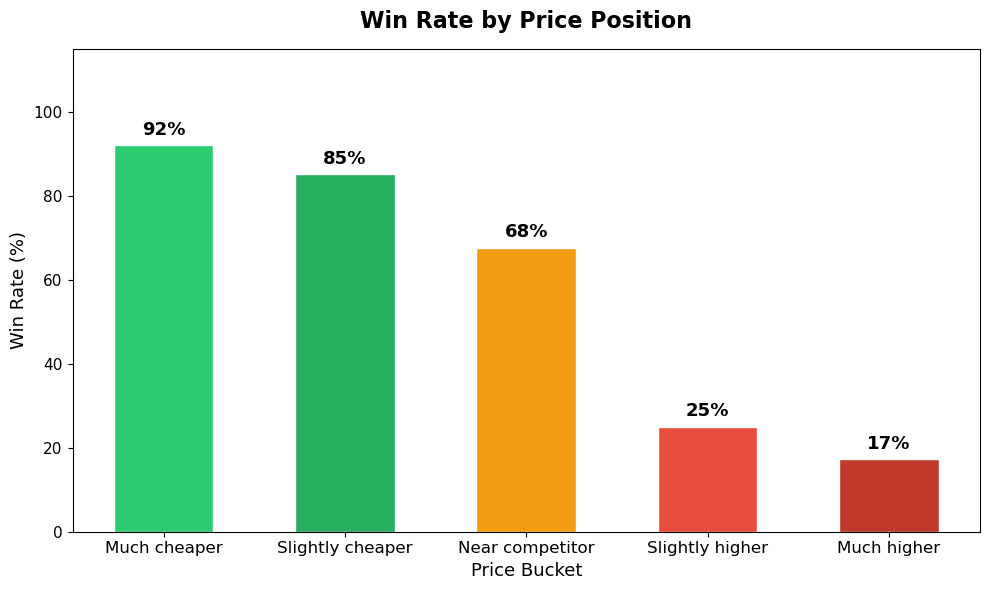

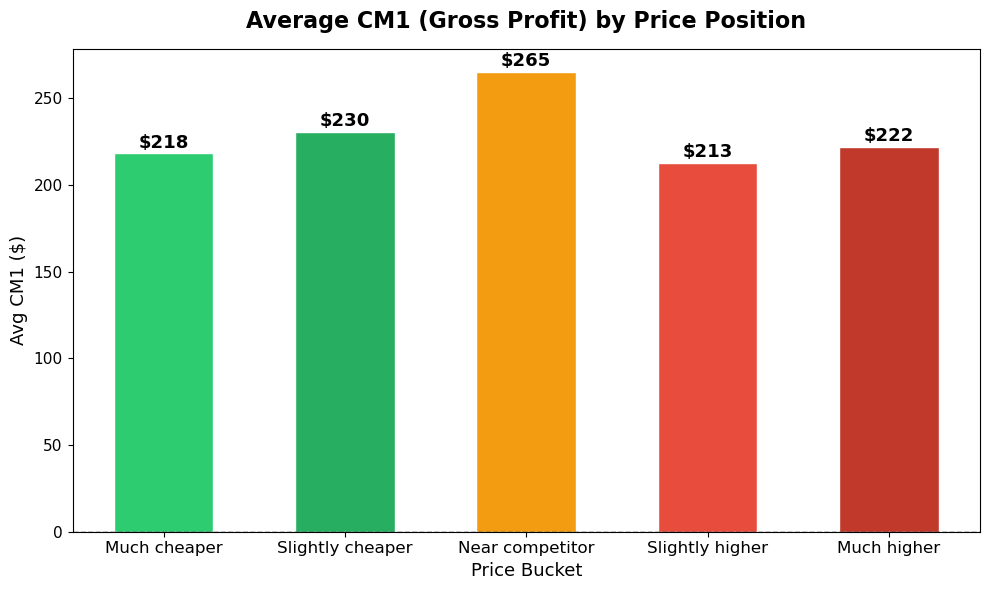

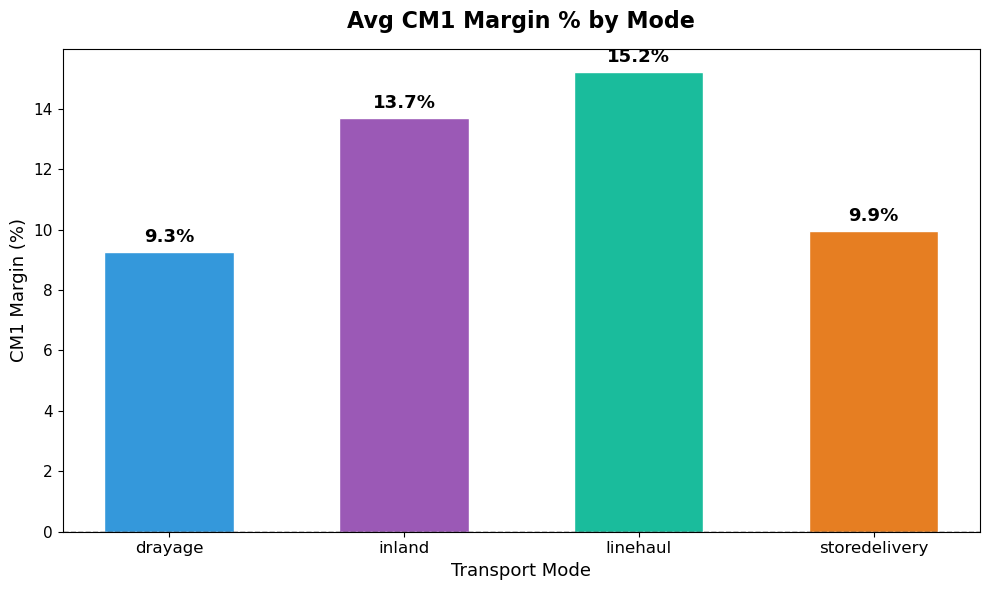

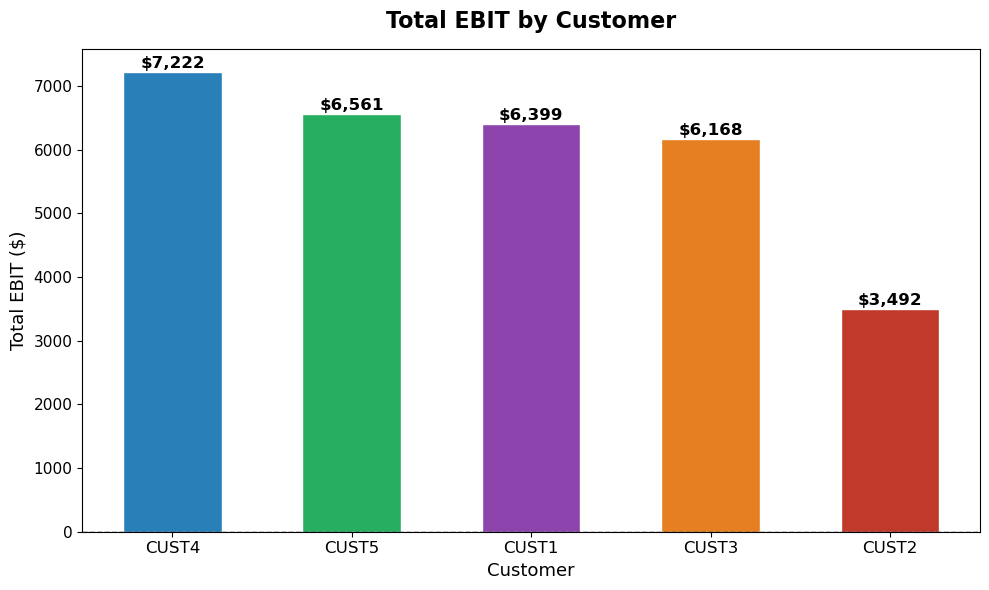

All 4 charts saved.


In [11]:
# Chart 1: Win Rate by Price Position 
fig1, ax1 = plt.subplots(figsize=(10, 6))

buckets = price_summary['price_bucket'].astype(str)
colors  = ['#2ecc71','#27ae60','#f39c12','#e74c3c','#c0392b']
wr_vals = price_summary['win_rate'] * 100

bars1 = ax1.bar(buckets, wr_vals, color=colors, edgecolor='white', width=0.55)
ax1.set_title('Win Rate by Price Position', fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel('Win Rate (%)', fontsize=13)
ax1.set_xlabel('Price Bucket', fontsize=13)
ax1.set_ylim(0, 115)
ax1.tick_params(axis='x', labelsize=12)
ax1.tick_params(axis='y', labelsize=11)
for b, v in zip(bars1, wr_vals):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 1.5,
             f'{v:.0f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('chart1_win_rate.png', dpi=150, bbox_inches='tight')
plt.show()


# Chart 2: Avg CM1 by Price Position 
fig2, ax2 = plt.subplots(figsize=(10, 6))

cm1_vals = price_summary['avg_cm1']

bars2 = ax2.bar(buckets, cm1_vals, color=colors, edgecolor='white', width=0.55)
ax2.set_title('Average CM1 (Gross Profit) by Price Position', fontsize=16, fontweight='bold', pad=15)
ax2.set_ylabel('Avg CM1 ($)', fontsize=13)
ax2.set_xlabel('Price Bucket', fontsize=13)
ax2.axhline(0, color='black', linewidth=1, linestyle='--')
ax2.tick_params(axis='x', labelsize=12)
ax2.tick_params(axis='y', labelsize=11)
for b, v in zip(bars2, cm1_vals):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
             f'${v:.0f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_cm1_by_bucket.png', dpi=150, bbox_inches='tight')
plt.show()


# Chart 3: Avg CM1 Margin % by Mode 
fig3, ax3 = plt.subplots(figsize=(10, 6))

mode_colors = ['#3498db','#9b59b6','#1abc9c','#e67e22']
cm1_by_mode = df.groupby('mode')['cm1_pct'].mean() * 100

bars3 = ax3.bar(cm1_by_mode.index, cm1_by_mode.values, color=mode_colors, edgecolor='white', width=0.55)
ax3.set_title('Avg CM1 Margin % by Mode', fontsize=16, fontweight='bold', pad=15)
ax3.set_ylabel('CM1 Margin (%)', fontsize=13)
ax3.set_xlabel('Transport Mode', fontsize=13)
ax3.axhline(0, color='black', linewidth=1, linestyle='--')
ax3.tick_params(axis='x', labelsize=12)
ax3.tick_params(axis='y', labelsize=11)
for b, v in zip(bars3, cm1_by_mode.values):
    ax3.text(b.get_x() + b.get_width()/2, b.get_height() + 0.2,
             f'{v:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_cm1_by_mode.png', dpi=150, bbox_inches='tight')
plt.show()


# Chart 4: Total EBIT by Customer 
fig4, ax4 = plt.subplots(figsize=(10, 6))

ebit_by_customer = df.groupby('customer_id')['ebit'].sum().sort_values(ascending=False)
cust_colors = ['#2980b9','#27ae60','#8e44ad','#e67e22','#c0392b']

bars4 = ax4.bar(ebit_by_customer.index, ebit_by_customer.values, color=cust_colors, edgecolor='white', width=0.55)
ax4.set_title('Total EBIT by Customer', fontsize=16, fontweight='bold', pad=15)
ax4.set_ylabel('Total EBIT ($)', fontsize=13)
ax4.set_xlabel('Customer', fontsize=13)
ax4.axhline(0, color='black', linewidth=1, linestyle='--')
ax4.tick_params(axis='x', labelsize=12)
ax4.tick_params(axis='y', labelsize=11)
for b, v in zip(bars4, ebit_by_customer.values):
    ax4.text(b.get_x() + b.get_width()/2, b.get_height() + 20,
             f'${v:,.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('chart4_ebit_by_customer.png', dpi=150, bbox_inches='tight')
plt.show()

print("All 4 charts saved.")

## Final Recommendations

### What the analysis shows

1. Win rate drops sharply once we are more than 3% above the competitor.
   The near-competitor zone is where service and relationship decide outcomes.
2. Linehaul and inland are the most profitable modes — protect margin here.
3. Drayage and store delivery have the thinnest margins and the most loss-making shipments.
4. Some customers generate high revenue but low EBIT — they need repricing attention.
5. "Much cheaper" wins are a warning signal — we may be systematically underpricing certain lanes.

### Recommended actions

- **Reprice shipments in the "Slightly higher" bucket** — we lose over 70% of these bids.
  A small price reduction or cost improvement could recover significant volume at healthy margin.
- **Audit "Much cheaper" wins** to check if those lanes can sustain a higher price
  without losing the business.
- **Review all negative-EBIT drayage and store delivery lanes** for repricing or exit at next tender.
- **Invest in service quality in the near-competitor zone** — a 55% win rate here
  can be improved without dropping price, through better reliability and capacity guarantees.
- **Schedule quarterly customer profitability reviews** to catch margin erosion early
  before it becomes a P&L problem.